In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [ ]:
##Load Fashion-MNIST Dataset


train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True
)


# Images
X = train_dataset.data.numpy()
X = X.reshape(X.shape[0], 28*28)
# Labels
y = train_dataset.targets.numpy()






In [ ]:
##Data Preprocessing

# Check missing values
print(np.isnan(X).sum())

# Split dataset
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



0


In [ ]:
##Data Augmentation

noise_factor=0.05
num_aug=1

aug_samples=[X_train]
aug_labels=[y_train]

for i in range(num_aug):
    noise=np.random.normal(0,noise_factor,X_train.shape)
    aug_samples.append(X_train+noise)
    aug_labels.append(y_train)

X_train_final = np.vstack(aug_samples)
y_train_final = np.vstack(aug_labels)

In [ ]:
# # Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)



y_train = torch.tensor(y_train, dtype=torch.long).view(-1)
y_val   = torch.tensor(y_val, dtype=torch.long).view(-1)
y_test  = torch.tensor(y_test, dtype=torch.long).view(-1)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [ ]:
### MODEL - EXPERIMENT 1 ReLU


model1 = nn.Sequential(
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),


    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 10)
)

### MODEL - EXPERIMENT 2 Tanh


model2 = nn.Sequential(
    nn.Linear(784, 64),
    nn.BatchNorm1d(64),
    nn.Tanh(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.Tanh(),
    nn.Dropout(0.3),



    nn.Linear(32, 10)
)



In [ ]:
##OPTIMIZERS , LOSS , SCHEDULER
optimizer1 = optim.Adam(model1.parameters(), lr=0.0001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=10, gamma=0.1)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=0.1)



In [ ]:
##TRAIN
def train_model(model, train_loader, val_loader, optimizer, model_name,epochs=50):

    print(f"\n STARTING TRAINING: {model_name}\n")

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        print(f"{model_name} | Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")




    return train_losses, val_losses, model



In [ ]:

train1, val1, model1 = train_model(model1, train_loader, val_loader, optimizer1 , "Model 1", epochs=50)
train2, val2, model2 = train_model(model2, train_loader, val_loader, optimizer2 ,"Model 2", epochs=50)


 STARTING TRAINING: Model 1

Model 1 | Epoch 1 | Train Loss: 0.9362 | Val Loss: 0.5649
Model 1 | Epoch 2 | Train Loss: 0.5560 | Val Loss: 0.4449
Model 1 | Epoch 3 | Train Loss: 0.4758 | Val Loss: 0.3990
Model 1 | Epoch 4 | Train Loss: 0.4293 | Val Loss: 0.3726
Model 1 | Epoch 5 | Train Loss: 0.3998 | Val Loss: 0.3586
Model 1 | Epoch 6 | Train Loss: 0.3845 | Val Loss: 0.3496
Model 1 | Epoch 7 | Train Loss: 0.3670 | Val Loss: 0.3350
Model 1 | Epoch 8 | Train Loss: 0.3492 | Val Loss: 0.3316
Model 1 | Epoch 9 | Train Loss: 0.3381 | Val Loss: 0.3251
Model 1 | Epoch 10 | Train Loss: 0.3299 | Val Loss: 0.3204
Model 1 | Epoch 11 | Train Loss: 0.3167 | Val Loss: 0.3152
Model 1 | Epoch 12 | Train Loss: 0.3148 | Val Loss: 0.3130
Model 1 | Epoch 13 | Train Loss: 0.3029 | Val Loss: 0.3102
Model 1 | Epoch 14 | Train Loss: 0.2954 | Val Loss: 0.3056
Model 1 | Epoch 15 | Train Loss: 0.2814 | Val Loss: 0.3076
Model 1 | Epoch 16 | Train Loss: 0.2785 | Val Loss: 0.3044
Model 1 | Epoch 17 | Train Loss: 0.

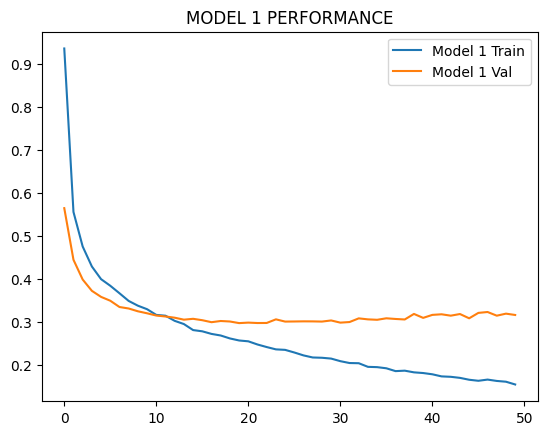

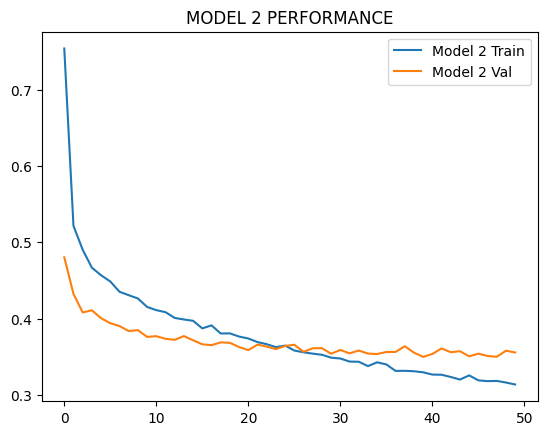

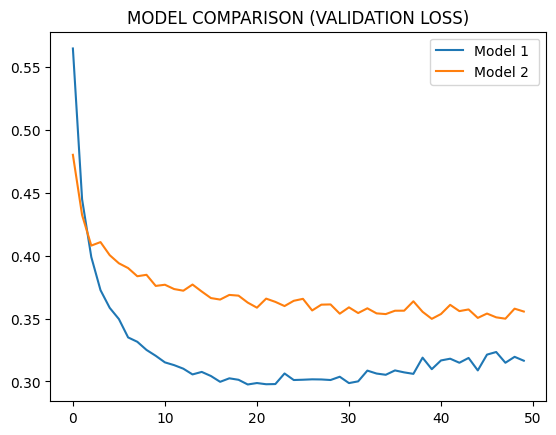

In [ ]:
##PLOT

plt.plot(train1, label="Model 1 Train")
plt.plot(val1, label="Model 1 Val")
plt.title("MODEL 1 PERFORMANCE")
plt.legend()
plt.show()

plt.plot(train2, label="Model 2 Train")
plt.plot(val2, label="Model 2 Val")
plt.title("MODEL 2 PERFORMANCE")
plt.legend()
plt.show()

plt.plot(val1, label="Model 1 ")
plt.plot(val2, label="Model 2 ")
plt.title("MODEL COMPARISON (VALIDATION LOSS)")
plt.legend()
plt.show()

In [ ]:
def evaluate(model, name):

    print(f"\n TESTING {name}...\n")

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    acc = 100 * correct / total

    print(f"{name} Accuracy: {acc:.2f}%")

    return acc


acc1 = evaluate(model1, "MODEL 1 (ReLU)")
acc2 = evaluate(model2, "MODEL 2 (Tanh)")


 TESTING MODEL 1 (ReLU)...

MODEL 1 (ReLU) Accuracy: 90.17%

 TESTING MODEL 2 (Tanh)...

MODEL 2 (Tanh) Accuracy: 88.14%



 FINAL COMPARISON RESULT

Model 1 Accuracy: 90.17% (ReLU )
Model 2 Accuracy: 88.14% (Tanh )


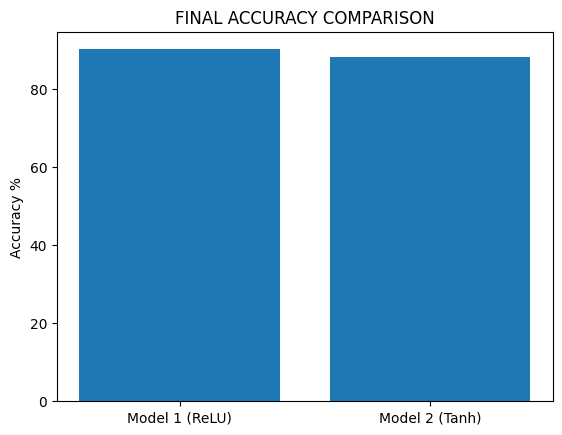

In [ ]:
# ============================================
# VISUALIZATION
# ============================================

print("\n FINAL COMPARISON RESULT\n")

print(f"Model 1 Accuracy: {acc1:.2f}% (ReLU )")
print(f"Model 2 Accuracy: {acc2:.2f}% (Tanh )")

plt.bar(
    ["Model 1 (ReLU)", "Model 2 (Tanh)"],
    [acc1, acc2]
)

plt.title("FINAL ACCURACY COMPARISON")
plt.ylabel("Accuracy %")
plt.show()





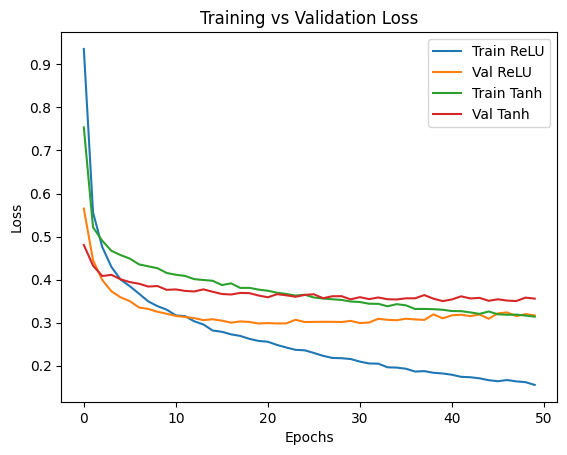

In [ ]:
plt.plot(train1, label="Train ReLU")
plt.plot(val1, label="Val ReLU")

plt.plot(train2, label="Train Tanh")
plt.plot(val2, label="Val Tanh")

plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
